# Importing required packages and creating dataset
## Using only cropped training set

In [11]:
# Dataset import
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [12]:
def plot_training_history(train_loss, val_loss, train_acc, val_acc, title="Model Training Log"):
    fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

    # Graphique de la Loss
    axes[0].plot(train_loss, label="Training", marker='o', ls='--')
    axes[0].plot(val_loss, label="Validation", marker='s')
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epochs")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Graphique de l'Accuracy
    axes[1].plot(train_acc, label="Training", marker='o', ls='--')
    axes[1].plot(val_acc, label="Validation", marker='s')
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epochs")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_performance_metrics(y_true, y_pred, labels_dict):
    """
    labels_dict: Dictionnaire {index: nom_de_la_classe} pour l'affichage
    """
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    label_names = [labels_dict[i] for i in range(len(labels_dict))]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)

    plt.title(f"Confusion Matrix (Overall Acc: {acc:.2%})")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=label_names))


def visualize_predictions(model, test_data, labels_dict, n_images=5):
    model.eval()
    plt.figure(figsize=(20, 4))

    # Sélectionner n images aléatoires du set de test
    indices = np.random.choice(len(test_data), n_images)

    for i, idx in enumerate(indices):
        path, true_idx = test_data[idx, 0], test_data[idx, 1]

        # Prédiction (réutilisation de ta logique)
        img_pil = Image.open(path).convert("RGB")
        img_tensor = transform(np.array(img_pil)).unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(img_tensor)
            pred_idx = out.argmax(1).item()
            prob = out[0][pred_idx].item()

        plt.subplot(1, n_images, i + 1)
        plt.imshow(img_pil)
        color = 'green' if pred_idx == true_idx else 'red'
        plt.title(f"P: {labels_dict[pred_idx]} ({prob:.1%})\nA: {labels_dict[true_idx]}", color=color)
        plt.axis('off')
    plt.show()

In [13]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from torchvision import transforms

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from copy import deepcopy

from PIL import Image

import random

def create_df(path):
    dd = {"images": [], "labels": []}
    for i in os.listdir(path):
        img_dir = os.path.join(path, i)
        dirs = os.listdir(img_dir)
        index = 0
        for j in dirs:
            dd["images"] += [os.path.join(img_dir, j)]
            dd["labels"] += [i]
            index += 1
            if index == 1000:
                break

    return pd.DataFrame(dd)

df = create_df("/kaggle/input/brain-tumor-mri-dataset/Training")

index_label = dict()
label_index = dict()

for i, j in enumerate(df["labels"].unique()):
    index_label[i] = j
    label_index[j] = i

df["labels"] = df["labels"].map(label_index)

In [14]:
# Instanciate the student model

from torchvision.models import resnet18, ResNet18_Weights

# Chargement d'un ResNet18 plus léger
student_base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
num_ftrs_student = student_base.fc.in_features
student_base.fc = nn.Linear(num_ftrs_student, OUT_SIZE)

# On utilise la même structure que ton wrapper précédent
student_model = ResNet(student_base).to(device)

# Le Teacher est ton best_model déjà entraîné
teacher_model = best_model
teacher_model.eval() # Le professeur ne change plus

ResNet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0)

In [3]:
!ls /kaggle/input/brain-tumor-mri-dataset/Training/glioma

Tr-gl_1000.jpg	Tr-gl_1253.jpg	Tr-gl_244.jpg  Tr-gl_497.jpg  Tr-gl_749.jpg
Tr-gl_1001.jpg	Tr-gl_1254.jpg	Tr-gl_245.jpg  Tr-gl_498.jpg  Tr-gl_74.jpg
Tr-gl_1002.jpg	Tr-gl_1255.jpg	Tr-gl_246.jpg  Tr-gl_499.jpg  Tr-gl_750.jpg
Tr-gl_1003.jpg	Tr-gl_1256.jpg	Tr-gl_247.jpg  Tr-gl_49.jpg   Tr-gl_751.jpg
Tr-gl_1004.jpg	Tr-gl_1257.jpg	Tr-gl_248.jpg  Tr-gl_4.jpg    Tr-gl_752.jpg
Tr-gl_1005.jpg	Tr-gl_1258.jpg	Tr-gl_249.jpg  Tr-gl_500.jpg  Tr-gl_753.jpg
Tr-gl_1006.jpg	Tr-gl_1259.jpg	Tr-gl_24.jpg   Tr-gl_501.jpg  Tr-gl_754.jpg
Tr-gl_1007.jpg	Tr-gl_125.jpg	Tr-gl_250.jpg  Tr-gl_502.jpg  Tr-gl_755.jpg
Tr-gl_1008.jpg	Tr-gl_1260.jpg	Tr-gl_251.jpg  Tr-gl_503.jpg  Tr-gl_756.jpg
Tr-gl_1009.jpg	Tr-gl_1261.jpg	Tr-gl_252.jpg  Tr-gl_504.jpg  Tr-gl_757.jpg
Tr-gl_100.jpg	Tr-gl_1262.jpg	Tr-gl_253.jpg  Tr-gl_505.jpg  Tr-gl_758.jpg
Tr-gl_1010.jpg	Tr-gl_1263.jpg	Tr-gl_254.jpg  Tr-gl_506.jpg  Tr-gl_759.jpg
Tr-gl_1011.jpg	Tr-gl_1264.jpg	Tr-gl_255.jpg  Tr-gl_507.jpg  Tr-gl_75.jpg
Tr-gl_1012.jpg	Tr-gl_1265.jpg	Tr-gl_256.jp

# Downloading ResNet and setting up training environment

In [18]:
EPOCHS = 3
STEP = 10
LR = 0.1
GAMMA = 0.1
IMG_SIZE = 224
BATCH = 16
OUT_SIZE = len(index_label)

class Pipeline(Dataset):
    def __init__(self, data, transform):
        super(Pipeline, self).__init__()
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, x):

        img, label = self.data[x, 0], self.data[x, 1]

        img = Image.open(img).convert("RGB")
        img = np.array(img)

        img = self.transform(img)
        return img, label

transform = transforms.Compose([transforms.ToPILImage(),
                               transforms.ToTensor(),
                               transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

train, val = train_test_split(df.values, random_state=42, test_size=0.25)
test, val = train_test_split(val, random_state=42, test_size=0.5)

train_ds = Pipeline(train, transform)
val_ds = Pipeline(val, transform)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False)

resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, OUT_SIZE)

class ResNet(nn.Module):
    def __init__(self, model):
        super(ResNet, self).__init__()
        self.model = model

    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ResNet(resnet)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP, gamma=GAMMA)

In [19]:
def distillation_loss(student_logits, labels, teacher_logits, T=3.0, alpha=0.5):
    """
    T: Température pour lisser les probabilités
    alpha: Poids accordé à la loss du professeur (0.5 = équilibre)
    """
    # Soft loss (Distillation)
    # On applique la température sur les log-probabilités
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        nn.functional.log_softmax(student_logits / T, dim=1),
        nn.functional.softmax(teacher_logits / T, dim=1)
    ) * (T * T)

    # Hard loss (Classification classique)
    hard_loss = nn.functional.cross_entropy(student_logits, labels)

    return alpha * soft_loss + (1.0 - alpha) * hard_loss

# Fine-tuning process log results

Epoch 1 train loss 0.05895008778572083 acc 0.8276666666666667 val loss 0.05754504287242889 acc 0.846
Epoch 2 train loss 0.051418937583764396 acc 0.9273333333333333 val loss 0.051231678128242496 acc 0.946
Epoch 3 train loss 0.05015099052588145 acc 0.945 val loss 0.05109688866138458 acc 0.95


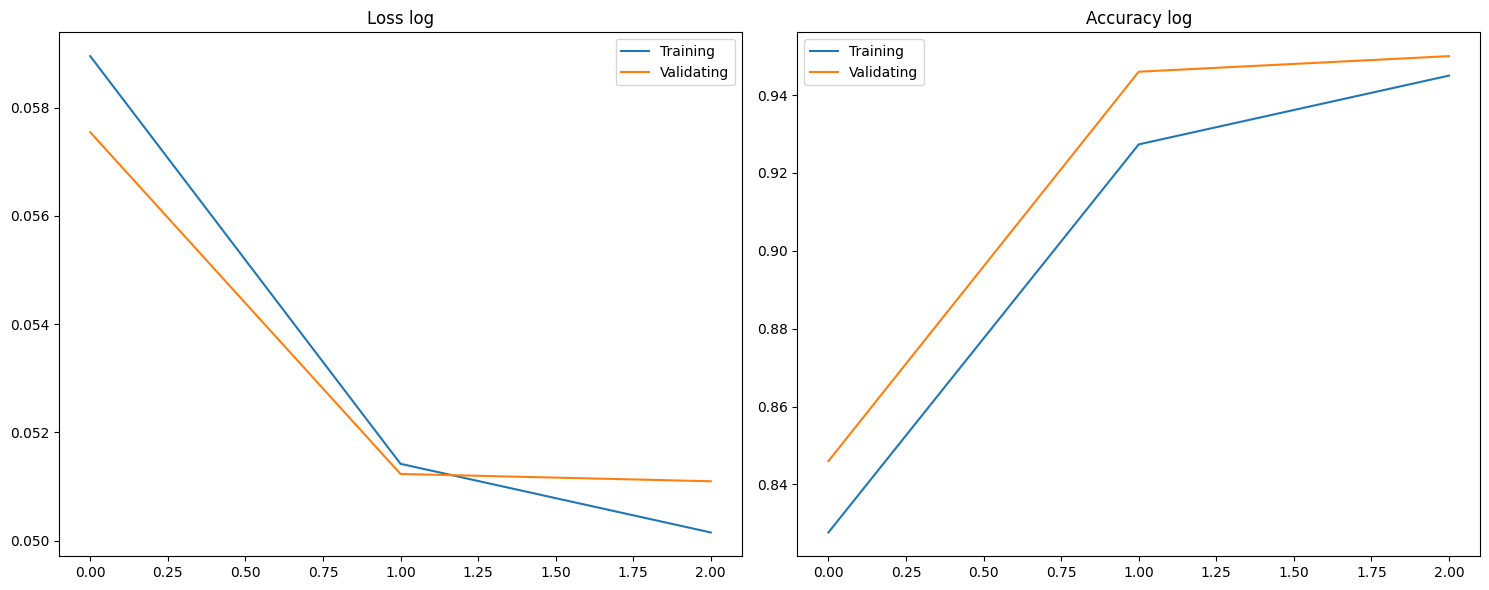

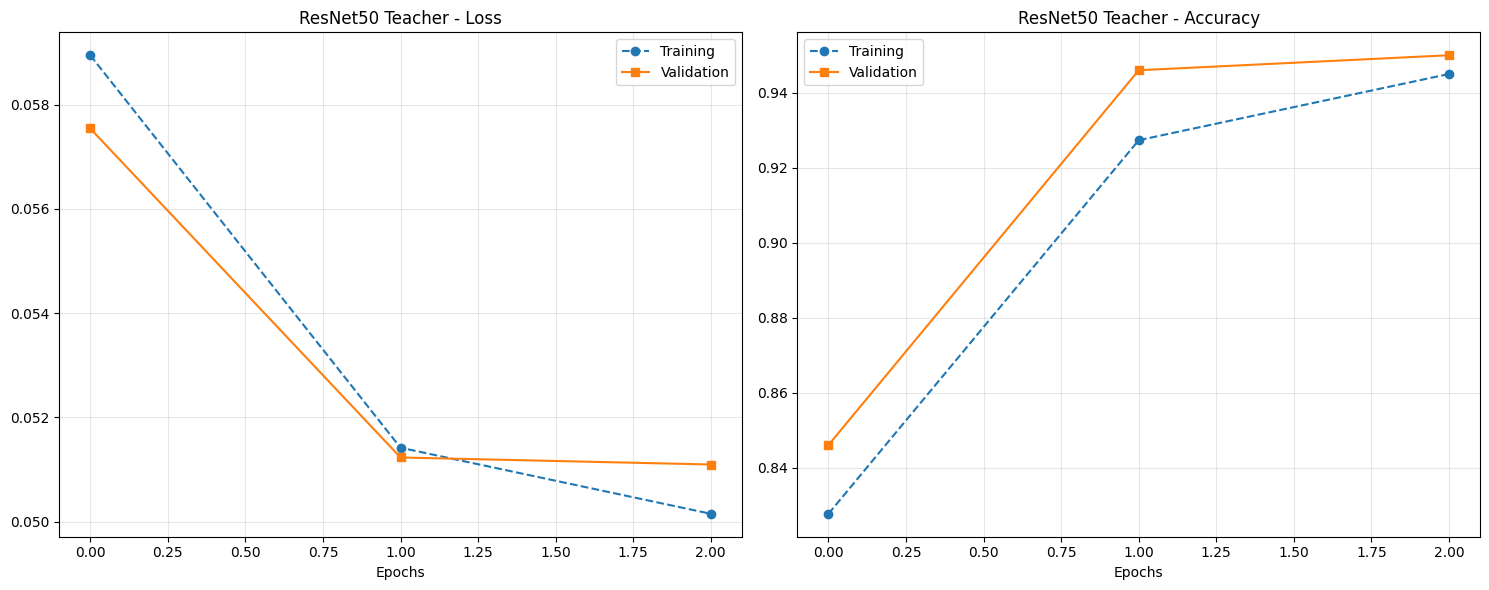

In [20]:
best_model = deepcopy(model)
best_acc = 0

train_loss = []
train_acc = []
val_acc = []
val_loss = []

for i in range(1, EPOCHS+1):
    model.train()

    diff = 0
    acc = 0
    total = 0

    for data, target in train_dl:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()

        out = model(data)
        loss = criterion(out, target)
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)

        loss.backward()
        optimizer.step()

    train_loss += [diff/total]
    train_acc += [acc/total]

    model.eval()

    diff = 0
    acc = 0
    total = 0

    with torch.no_grad():
        for data, target in val_dl:
            optimizer.zero_grad()
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            out = model(data)
            loss = criterion(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss += [diff/total]
    val_acc += [acc/total]

    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        best_model = deepcopy(model)

    scheduler.step()

    print("Epoch {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1], train_acc[-1],
                                                                   val_loss[-1], val_acc[-1]))

fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

index = 0

axes[index].plot(train_loss, label="Training")
axes[index].plot(val_loss, label="Validating")
axes[index].set_title("Loss log")
axes[index].legend()

index += 1

axes[index].plot(train_acc, label="Training")
axes[index].plot(val_acc, label="Validating")
axes[index].set_title("Accuracy log")
axes[index].legend()
plt.tight_layout()
plt.show()

plot_training_history(train_loss, val_loss, train_acc, val_acc, title="ResNet50 Teacher")

In [ ]:
# Student training loop

optimizer_student = torch.optim.Adam(student_model.parameters(), lr=0.001)
epochs_distill = 3

for epoch in range(1, epochs_distill + 1):
    student_model.train()
    total_loss = 0

    for data, target in train_dl:
        data, target = data.to(device), target.to(device)
        optimizer_student.zero_grad()

        # 1. Sortie du professeur (on ne calcule pas les gradients)
        with torch.no_grad():
            teacher_preds = teacher_model.model(data) # .model pour avoir les logits bruts

        # 2. Sortie de l'élève
        student_preds = student_model.model(data)

        # 3. Loss combinée
        loss = distillation_loss(student_preds, target, teacher_preds, T=3.0, alpha=0.7)

        loss.backward()
        optimizer_student.step()
        total_loss += loss.item()

    print(f"Epoch {epoch} | Distillation Loss: {total_loss/len(train_dl):.4f}")

Epoch 1 | Distillation Loss: 2.5969


# Fine-tuned ResNet50 inference results

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       129
           1       0.96      0.98      0.97       123
           2       0.98      0.96      0.97       135
           3       0.97      0.98      0.98       113

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



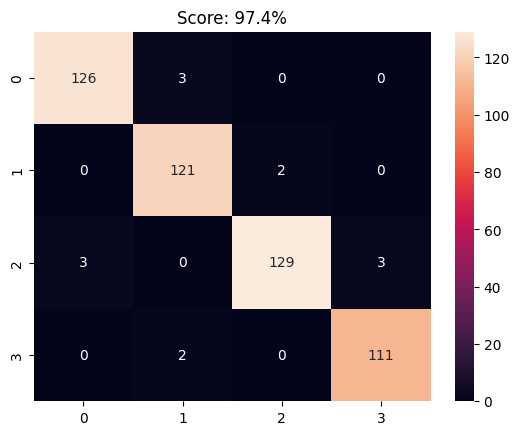

In [7]:
def predict(img):
    img = Image.open(img).convert("RGB")
    img = transform(np.array(img))
    img = img.view([1, 3, 224, 224])

    best_model.eval()
    with torch.no_grad():
        if torch.cuda.is_available():
            img = img.cuda()
        out = best_model(img)

    index = out.argmax(1).item()

    return index, round(out[0][index].item()*100, 2)

truth = []
preds = []
probas = []

np.random.shuffle(test)

for i in range(test.shape[0]):
    truth += [test[i, 1]]
    pred, proba = predict(test[i, 0])
    preds += [pred]
    probas += [proba]

score = accuracy_score(preds, truth)
print(classification_report(preds, truth))
sns.heatmap(confusion_matrix(preds, truth), annot=True, fmt='d')
plt.title("Score: {}%".format(round(score*100, 2)))
plt.show()